In [4]:
import numpy as np
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForQuestionAnswering,
    AutoModelForSeq2SeqLM,
    Seq2SeqTrainer,
    EarlyStoppingCallback,
    Seq2SeqTrainingArguments,
)

import torch

c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)
print(torch.cuda.get_device_name(0))

Using device: cuda
NVIDIA GeForce RTX 3050 Ti Laptop GPU


In [ ]:
# Quiz Generation (T5)
quiz_tokenizer = AutoTokenizer.from_pretrained("valhalla/t5-base-qg-hl")
quiz_model     = AutoModelForSeq2SeqLM.from_pretrained("valhalla/t5-base-qg-hl")

# Move to GPU
quiz_model = quiz_model.to(device)

print("T5 model loaded!")


Loading weights: 100%|██████████| 260/260 [00:00<00:00, 21347.98it/s]


T5 model loaded!


In [7]:
# QA & Quiz Generation
squad = load_dataset("squad", split="train")

print("SQuAD loaded       →", len(squad), "samples")

SQuAD loaded       → 87599 samples


In [8]:
print("── SQuAD Sample ──")
print("Context :", squad[0]['context'][:300])
print("Question:", squad[0]['question'])
print("Answer  :", squad[0]['answers'])

── SQuAD Sample ──
Context : Architecturally, the school has a Catholic character. Atop the Main Building's gold dome is a golden statue of the Virgin Mary. Immediately in front of the Main Building and facing it, is a copper statue of Christ with arms upraised with the legend "Venite Ad Me Omnes". Next to the Main Building is 
Question: To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?
Answer  : {'text': ['Saint Bernadette Soubirous'], 'answer_start': [515]}


# EDA

In [9]:
squad_df = pd.DataFrame({
    'question' : [x['question']           for x in squad],
    'context'  : [x['context']            for x in squad],
    'answer'   : [x['answers']['text'][0] for x in squad],
})

print("SQuAD shape :", squad_df.shape)

SQuAD shape : (87599, 3)


In [10]:
squad_df.head()

,question,context,answer
0,To whom did the Virgin Mary allegedly appear i...,"Architecturally, the school has a Catholic cha...",Saint Bernadette Soubirous
1,What is in front of the Notre Dame Main Building?,"Architecturally, the school has a Catholic cha...",a copper statue of Christ
2,The Basilica of the Sacred heart at Notre Dame...,"Architecturally, the school has a Catholic cha...",the Main Building
3,What is the Grotto at Notre Dame?,"Architecturally, the school has a Catholic cha...",a Marian place of prayer and reflection
4,What sits on top of the Main Building at Notre...,"Architecturally, the school has a Catholic cha...",a golden statue of the Virgin Mary


In [11]:
token_fun = lambda x: len(x.split())

squad_df['question_len'] = squad_df['question'].apply(token_fun)
squad_df['context_len']  = squad_df['context'].apply(token_fun)
squad_df['answer_len']   = squad_df['answer'].apply(token_fun)

print("── SQuAD ──")
print(squad_df[['question_len','context_len','answer_len']].describe().round(1))

── SQuAD ──
       question_len  context_len  answer_len
count       87599.0      87599.0     87599.0
mean           10.1        119.8         3.2
std             3.6         49.4         3.4
min             1.0         20.0         1.0
25%             8.0         89.0         1.0
50%            10.0        110.0         2.0
75%            12.0        142.0         3.0
max            40.0        653.0        43.0


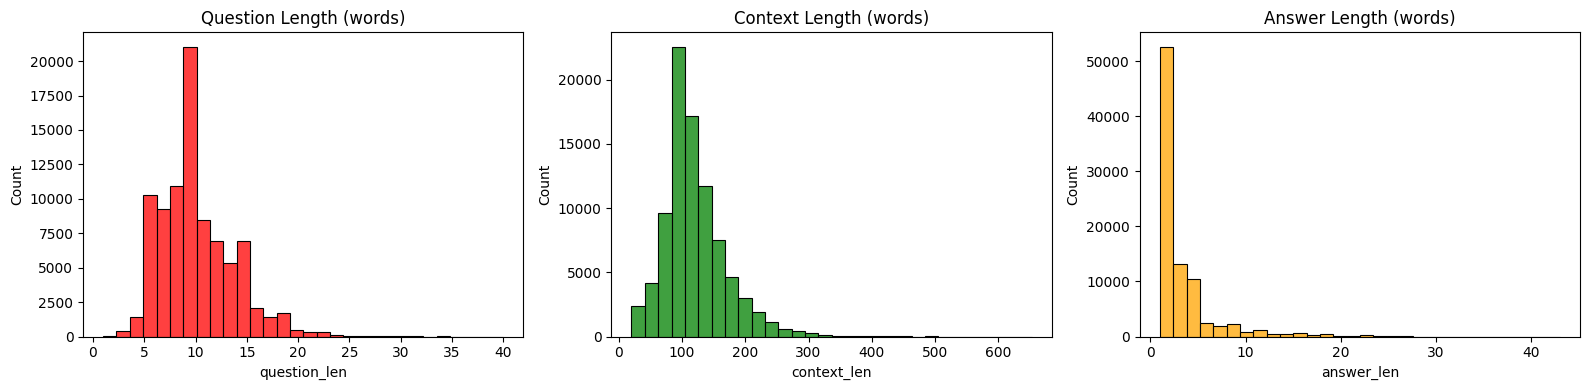

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(squad_df['question_len'], bins=30, ax=axes[0], color='red')
axes[0].set_title('Question Length (words)')

sns.histplot(squad_df['context_len'], bins=30, ax=axes[1], color='green')
axes[1].set_title('Context Length (words)')

sns.histplot(squad_df['answer_len'], bins=30, ax=axes[2], color='orange')
axes[2].set_title('Answer Length (words)')

plt.tight_layout()
plt.show()

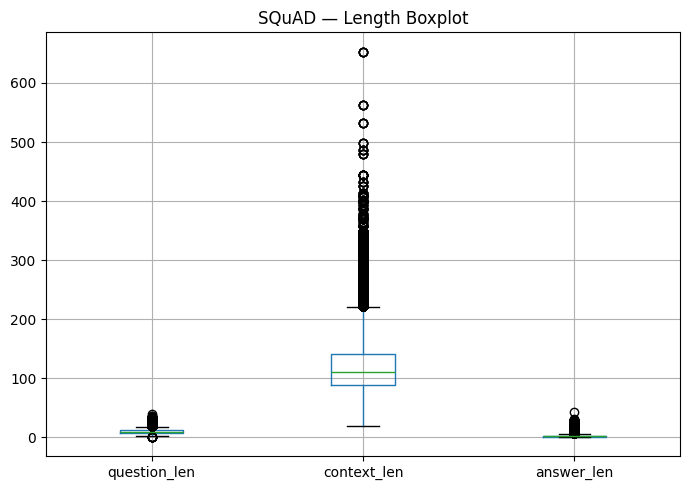

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))

squad_df[['question_len','context_len','answer_len']].boxplot(ax=ax)
ax.set_title('SQuAD — Length Boxplot')

plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_23896\2336448443.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts.keys()), y=list(counts.values()), palette='Set2')


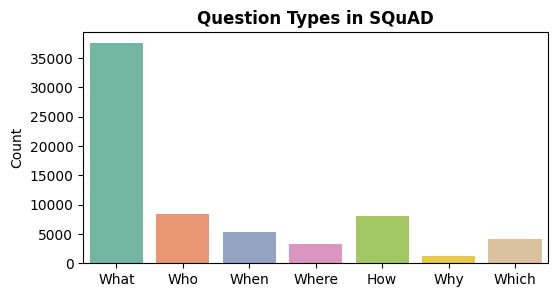

In [14]:
question_words = ['What', 'Who', 'When', 'Where', 'How', 'Why', 'Which']

counts = {
    w: squad_df['question'].str.startswith(w).sum()
    for w in question_words
}

plt.figure(figsize=(6, 3))
sns.barplot(x=list(counts.keys()), y=list(counts.values()), palette='Set2')
plt.title('Question Types in SQuAD', fontweight='bold')
plt.ylabel('Count')
plt.show()

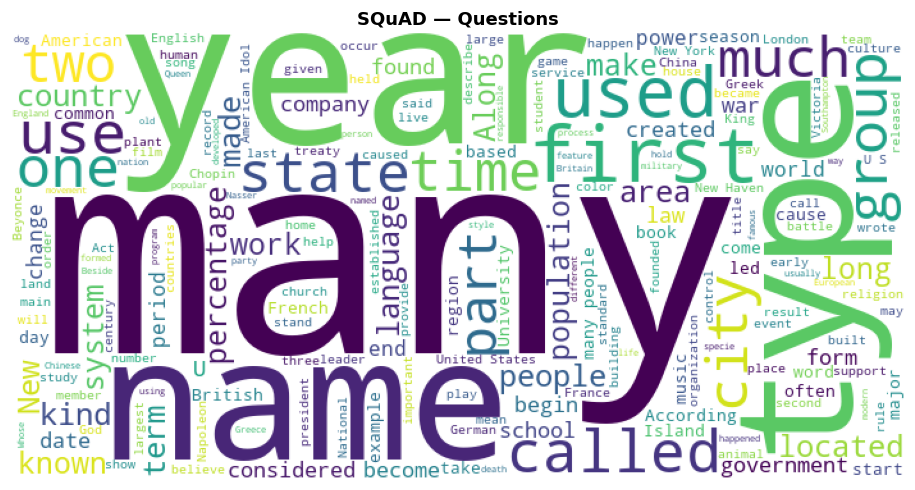

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

wc1 = WordCloud(width=700, height=350, background_color='white').generate(
    ' '.join(squad_df['question'])
)
ax.imshow(wc1)
ax.axis('off')
ax.set_title('SQuAD — Questions', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Preprocessing

In [16]:
def clean_text(text):
    text = text.strip()
    text = re.sub(r'\s+', ' ', text)
    return text

squad_df['question'] = squad_df['question'].apply(clean_text)
squad_df['context']  = squad_df['context'].apply(clean_text)
squad_df['answer']   = squad_df['answer'].apply(clean_text)

print("Cleaning done!")

Cleaning done!


In [17]:
print("── SQuAD ──")
print(squad_df.isnull().sum())

── SQuAD ──
question        0
context         0
answer          0
question_len    0
context_len     0
answer_len      0
dtype: int64


In [18]:
squad_df = squad_df.dropna().reset_index(drop=True)

print("SQuAD :", len(squad_df), "samples")

SQuAD : 87599 samples


In [19]:
def get_iqr_bounds(df, col):
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return lower, upper

In [20]:
print("── SQuAD ──")
for col in ['question_len', 'context_len', 'answer_len']:
    lower, upper = get_iqr_bounds(squad_df, col)
    outliers = squad_df[(squad_df[col] < lower) | (squad_df[col] > upper)]
    print(f"{col} → Lower: {lower:.1f} | Upper: {upper:.1f} | Outliers: {len(outliers)}")

── SQuAD ──
question_len → Lower: 2.0 | Upper: 18.0 | Outliers: 2109
context_len → Lower: 9.5 | Upper: 221.5 | Outliers: 3533
answer_len → Lower: -2.0 | Upper: 6.0 | Outliers: 8935


In [21]:
for col in ['question_len', 'context_len', 'answer_len']:
    lower, upper = get_iqr_bounds(squad_df, col)
    squad_df = squad_df[(squad_df[col] >= lower) & (squad_df[col] <= upper)]
squad_df = squad_df.reset_index(drop=True)

print("After removing outliers:")
print("SQuAD :", len(squad_df), "samples")

After removing outliers:
SQuAD : 76731 samples


In [ ]:
def make_qg_input(row):
    context = row['context']
    answer  = row['answer']
    idx = context.lower().find(answer.lower())
    if idx == -1:
        return "generate question: " + context
    before = context[:idx]
    match  = context[idx : idx + len(answer)]
    after  = context[idx + len(answer):]
    return f"generate question: {before}<hl> {match} <hl>{after}"

squad_df['quiz_input'] = squad_df.apply(make_qg_input, axis=1)
squad_df['qa_input']   = squad_df['question'] + " [SEP] " + squad_df['context']

print("── QA Input ──")
print(squad_df['qa_input'][0][:200])
print("\n── Quiz Input (Highlighted) ──")
print(squad_df['quiz_input'][0][:200])


── QA Input ──
To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France? [SEP] Architecturally, the school has a Catholic character. Atop the Main Building's gold dome is a golden statue of the Virgin 

── Quiz Input (Highlighted) ──
generate question: Architecturally, the school has a Catholic character. Atop the Main Building's gold dome is a golden statue of the Virgin Mary. Immediately in front of the Main Building and facing 


In [23]:
from sklearn.model_selection import train_test_split

squad_train, squad_test = train_test_split(squad_df, test_size=0.2, random_state=42)

squad_train = squad_train.sample(13000, random_state=42)
squad_test  = squad_test.sample(3000, random_state=42)

print("SQuAD → Train:", len(squad_train), "| Test:", len(squad_test))

SQuAD → Train: 13000 | Test: 3000


# Modeling & Training

In [ ]:
from torch.utils.data import Dataset

class QADataset(Dataset):

    def __init__(self, df, tokenizer):
        self.df = df.reset_index(drop=True)

        self.encodings = tokenizer(
            self.df['question'].tolist(),
            self.df['context'].tolist(),
            truncation='only_second',    
            max_length=384,             
            padding=True,
            return_offsets_mapping=True,
            return_tensors='pt'
        )

        self.start_positions = []
        self.end_positions   = []
        self.valid_mask      = []       

        for idx in range(len(self.df)):
            answer  = self.df['answer'].iloc[idx]
            context = self.df['context'].iloc[idx]

            start_char = context.find(answer)

            if start_char == -1:
                self.start_positions.append(0)
                self.end_positions.append(0)
                self.valid_mask.append(False)
                continue

            self.valid_mask.append(True)
            end_char = start_char + len(answer)

            seq_ids        = self.encodings.sequence_ids(idx)
            offset_mapping = self.encodings['offset_mapping'][idx]

            start_pos, end_pos = 0, 0

            for i, (seq_id, (s, e)) in enumerate(zip(seq_ids, offset_mapping)):
                if seq_id != 1:  
                    continue
                s, e = int(s), int(e)
                if s <= start_char < e:
                    start_pos = i
                if s < end_char <= e:
                    end_pos = i
                    break

            self.start_positions.append(start_pos)
            self.end_positions.append(end_pos)

        valid_indices = [i for i, v in enumerate(self.valid_mask) if v]
        if len(valid_indices) < len(self.df):
            skipped = len(self.df) - len(valid_indices)
            print(f"  ⚠️  Skipped {skipped} samples (answer not found in context)")

            self.encodings = {
                'input_ids'      : self.encodings['input_ids'][valid_indices],
                'attention_mask' : self.encodings['attention_mask'][valid_indices],
            }
            self.start_positions = [self.start_positions[i] for i in valid_indices]
            self.end_positions   = [self.end_positions[i]   for i in valid_indices]

    def __len__(self):
        return len(self.start_positions)

    def __getitem__(self, idx):
        return {
            'input_ids'       : self.encodings['input_ids'][idx],
            'attention_mask'  : self.encodings['attention_mask'][idx],
            'start_positions' : torch.tensor(self.start_positions[idx]),
            'end_positions'   : torch.tensor(self.end_positions[idx])
        }


# ── BART & T5 (Seq2Seq) ── Pre-tokenized ──
class Seq2SeqDataset(Dataset):

    def __init__(self, df, tokenizer, input_col, target_col,
                 input_max_len, target_max_len, prefix=""):

        self.df = df.reset_index(drop=True)

        inputs  = [prefix + str(x) for x in self.df[input_col]]
        targets = [str(x)          for x in self.df[target_col]]

        self.src_enc = tokenizer(
            inputs,
            truncation=True,
            max_length=input_max_len,
            padding=True,
            return_tensors='pt'
        )

        tgt_enc = tokenizer(
            targets,
            truncation=True,
            max_length=target_max_len,
            padding=True,
            return_tensors='pt'
        )

        self.labels = tgt_enc['input_ids'].clone()
        self.labels[self.labels == tokenizer.pad_token_id] = -100

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        return {
            'input_ids'     : self.src_enc['input_ids'][idx],
            'attention_mask': self.src_enc['attention_mask'][idx],
            'labels'        : self.labels[idx]
        }

print("Dataset classes ready!")


Dataset classes ready!


In [25]:
print("Pre-tokenizing Quiz datasets...")
quiz_train_ds = Seq2SeqDataset(
    squad_train, quiz_tokenizer,
    'quiz_input',
    'question',
    512,
    64,
    prefix=""
)
quiz_test_ds = Seq2SeqDataset(
    squad_test, quiz_tokenizer,
    'quiz_input',
    'question',
    512,
    64,
    prefix=""
)
print("Quiz done!")

print("\nQuiz → Train:", len(quiz_train_ds), "| Test:", len(quiz_test_ds))


Pre-tokenizing Quiz datasets...
Quiz done!

Quiz → Train: 13000 | Test: 3000


# Train T5 (Quiz Generation) 

In [26]:

quiz_trainer = Seq2SeqTrainer(
    model         = quiz_model,          
    train_dataset = quiz_train_ds,       
    eval_dataset  = quiz_test_ds,      
    callbacks     = [EarlyStoppingCallback(early_stopping_patience=2)],
    args          = Seq2SeqTrainingArguments(
        output_dir                  = './models_lg/quiz_model',
        num_train_epochs            = 3,
        learning_rate               = 3e-5,
        per_device_train_batch_size = 4,
        per_device_eval_batch_size  = 8,
        eval_strategy               = 'epoch',
        save_strategy               = 'epoch',
        load_best_model_at_end      = True,
        predict_with_generate       = True,
        fp16                        = True,
        warmup_steps                = 200,
        weight_decay                = 0.01,
        logging_steps               = 100,
    )
)

quiz_trainer.train()
print("T5 Quiz Generation Done!")


Epoch,Training Loss,Validation Loss
1,1.194615,1.068889
2,1.159582,1.071035
3,1.044253,1.071023


c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\User\.cache\huggingface\hub\models--valhalla--t5-base-qg-hl. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.20s/it]
[transformers] There were

T5 Quiz Generation Done!


# Save Models

In [27]:
import os

os.makedirs('./models_lg/quiz_model', exist_ok=True)

quiz_model.save_pretrained('./models_lg/quiz_model')
quiz_tokenizer.save_pretrained('./models_lg/quiz_model')

print("T5 model saved!")


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.60s/it]


T5 model saved!


✅ Loading from: checkpoint-9750


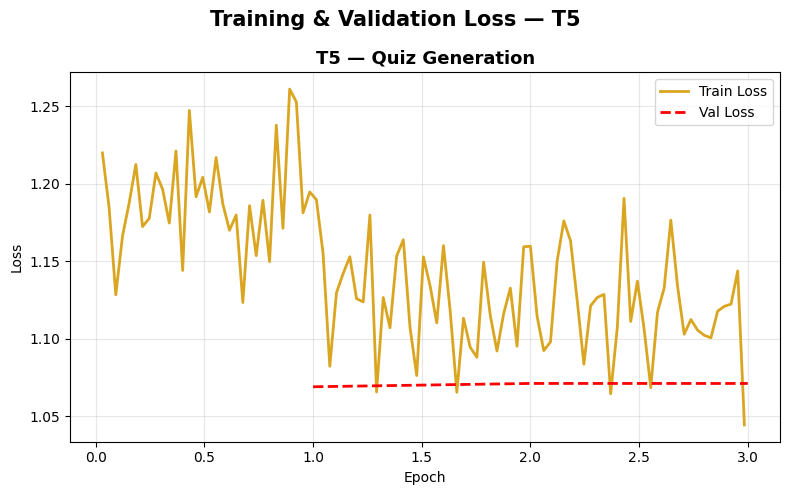

In [ ]:
import json
import os
import matplotlib.pyplot as plt

def load_log_history(model_path):
    
    main_path = f"{model_path}/trainer_state.json"
    if os.path.exists(main_path):
        with open(main_path, "r") as f:
            return json.load(f)["log_history"]
    
    checkpoints = sorted([
        d for d in os.listdir(model_path)
        if d.startswith("checkpoint-")
    ], key=lambda x: int(x.split("-")[1]))
    
    if checkpoints:
        last_checkpoint = checkpoints[-1]  
        ckpt_path = f"{model_path}/{last_checkpoint}/trainer_state.json"
        if os.path.exists(ckpt_path):
            print(f"✅ Loading from: {last_checkpoint}")
            with open(ckpt_path, "r") as f:
                return json.load(f)["log_history"]
    
    print(f"Can`t find trainer_state.json {model_path}")
    return []

def extract_losses(log_history):
    train_loss, eval_loss = [], []
    for x in log_history:
        if 'loss' in x and 'eval_loss' not in x:
            train_loss.append((x['epoch'], x['loss']))
        if 'eval_loss' in x:
            eval_loss.append((x['epoch'], x['eval_loss']))
    return train_loss, eval_loss

# logs ──
quiz_logs = load_log_history('./models_lg/quiz_model')

quiz_train, quiz_eval = extract_losses(quiz_logs)

# Loss Curves ──
fig, ax = plt.subplots(figsize=(8, 5))

if quiz_train:
    ax.plot([e for e,l in quiz_train], [l for e,l in quiz_train],
            label='Train Loss', color='goldenrod', linewidth=2)
if quiz_eval:
    ax.plot([e for e,l in quiz_eval], [l for e,l in quiz_eval],
            label='Val Loss', color='red', linewidth=2, linestyle='--')

ax.set_title('T5 — Quiz Generation', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Training & Validation Loss — T5', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [36]:
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import numpy as np

# ── ROUGE ──
scorer = rouge_scorer.RougeScorer(
    ['rouge1', 'rouge2', 'rougeL'],
    use_stemmer=True
)

rouge1_scores = []
rouge2_scores = []
rougeL_scores = []

for pred, ref in zip(quiz_preds, quiz_refs):
    scores = scorer.score(ref, pred)

    rouge1_scores.append(scores['rouge1'].fmeasure)
    rouge2_scores.append(scores['rouge2'].fmeasure)
    rougeL_scores.append(scores['rougeL'].fmeasure)

# ── BLEU-4 ──
smooth = SmoothingFunction().method1
bleu_scores = []

for pred, ref in zip(quiz_preds, quiz_refs):
    bleu = sentence_bleu(
        [ref.split()],
        pred.split(),
        smoothing_function=smooth
    )
    bleu_scores.append(bleu)

# ── Final Results ──
print("=" * 40)
print("   T5 — Quiz Generation Results")
print("=" * 40)

print("  ── ROUGE ──")
print(f"  ROUGE-1    : {np.mean(rouge1_scores):.4f}")
print(f"  ROUGE-2    : {np.mean(rouge2_scores):.4f}")
print(f"  ROUGE-L    : {np.mean(rougeL_scores):.4f}")

print("  ── BLEU ──")
print(f"  BLEU-4     : {np.mean(bleu_scores):.4f}")

print("=" * 40)

   T5 — Quiz Generation Results
  ── ROUGE ──
  ROUGE-1    : 0.6117
  ROUGE-2    : 0.3987
  ROUGE-L    : 0.5551
  ── BLEU ──
  BLEU-4     : 0.2492
